In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('data\\raw\\ember_data\\all_country_data_cleaned_merged.csv')
df.head()

,entity,entity code,date,series,generation_TWh,precipitation,solar,humidity,temperature
0,Argentina,ARG,01/01/2018,Bioenergy,0.02,10648.72,24.537102,9.435314,18.193195
1,Argentina,ARG,01/01/2018,Coal,0.26,10648.72,24.537102,9.435314,18.193195
2,Argentina,ARG,01/01/2018,Gas,7.79,10648.72,24.537102,9.435314,18.193195
3,Argentina,ARG,01/01/2018,Hydro,3.69,10648.72,24.537102,9.435314,18.193195
4,Argentina,ARG,01/01/2018,Nuclear,0.64,10648.72,24.537102,9.435314,18.193195


In [3]:
print('shape:', df.shape)
print('columns:', list(df.columns))
print(df.dtypes.head(20))
for c in ['date', 'Date', 'year', 'month', 'country', 'area', 'generation_TWh', 'electricity_generation', 'type', 'fuel', 'variable']:
    if c in df.columns:
        print(c, 'sample:', df[c].dropna().astype(str).head(3).tolist())

shape: (10513, 9)
columns: ['entity', 'entity code', 'date', 'series', 'generation_TWh', 'precipitation', 'solar', 'humidity', 'temperature']
entity             object
entity code        object
date               object
series             object
generation_TWh    float64
precipitation     float64
solar             float64
humidity          float64
temperature       float64
dtype: object
date sample: ['01/01/2018', '01/01/2018', '01/01/2018']
generation_TWh sample: ['0.02', '0.26', '7.79']


In [4]:
# Cell 1: Cài đặt và import thư viện cần thiết
import sys
import subprocess
import importlib

required_packages = [
    "numpy",
    "torch",
    "lightning",
    "pytorch-forecasting",
    "scikit-learn",
]

for pkg in required_packages:
    try:
        importlib.import_module(pkg.replace('-', '_'))
    except Exception:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

import numpy as np
import pandas as pd
import torch

from lightning.pytorch import Trainer, seed_everything
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor
from lightning.pytorch.loggers import CSVLogger

from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Torch: 2.9.1+cu126
CUDA available: True


In [5]:
# Cell 2: Load pre-model dataset (uu tien) hoac fallback tien xu ly tu raw
from pathlib import Path

seed_everything(42)

premodel_candidates = [
    Path('data/processed/tft_premodel_dataset.csv'),
    Path('../data/processed/tft_premodel_dataset.csv'),
]

premodel_path = None
for p in premodel_candidates:
    if p.exists():
        premodel_path = p
        break

if premodel_path is not None:
    data = pd.read_csv(premodel_path)
    data['date'] = pd.to_datetime(data['date'], errors='coerce')
    if 'month' in data.columns:
        data['month'] = data['month'].astype(str)
    print('Loaded premodel dataset from:', premodel_path)
else:
    print('Premodel dataset not found, fallback to raw preprocessing...')
    data = df.copy()
    data.columns = [c.strip() for c in data.columns]
    data['date'] = pd.to_datetime(data['date'], dayfirst=True, errors='coerce')
    data = data.dropna(subset=['date', 'entity', 'series', 'generation_TWh']).copy()
    data['date'] = data['date'].dt.to_period('M').dt.to_timestamp()

    data['series'] = data['series'].astype(str).str.strip()
    data = data[~data['series'].str.casefold().eq('total generation')].copy()

    # GIẢI QUYẾT ZERO VALUES TRONG TARGET & CÁC COLUMN SỐ LIỆU ĐỂ TRÁNH LỖI KHI TÍNH WAPE VÀ GIÚP MODEL ỔN ĐỊNH
    data['generation_TWh'] = pd.to_numeric(data['generation_TWh'], errors='coerce').clip(lower=1e-5) # Thay 0 bằng số epsilon rất nhỏ
    for c in ['precipitation', 'solar', 'humidity', 'temperature']:
        if c in data.columns:
            data[c] = pd.to_numeric(data[c], errors='coerce').clip(lower=0)

    data = data.drop_duplicates(subset=['entity', 'series', 'date'], keep='last')
    data = data.dropna(subset=['generation_TWh']).copy()

    weather_cols = [c for c in ['precipitation', 'solar', 'humidity', 'temperature'] if c in data.columns]
    group_cols = ['entity', 'series']
    for c in weather_cols:
        data[c] = data.groupby(group_cols)[c].transform(lambda s: s.ffill().bfill())
        data[c] = data[c].fillna(data[c].median())

    data = data.sort_values(['entity', 'series', 'date']).reset_index(drop=True)
    min_date = data['date'].min()
    data['time_idx'] = ((data['date'].dt.year - min_date.year) * 12 + (data['date'].dt.month - min_date.month)).astype(int)
    data['month_num'] = data['date'].dt.month.astype(int)
    data['month'] = data['month_num'].astype(str)
    data['month_sin'] = np.sin(2 * np.pi * data['month_num'] / 12.0)
    data['month_cos'] = np.cos(2 * np.pi * data['month_num'] / 12.0)

# Chắc chắn rằng sau khi load dataset, target không chứa gía trị đúng = 0 (gây vỡ Loss hoặc nhiễu MAE/WAPE tỷ lệ phần trăm)
data['generation_TWh'] = data['generation_TWh'].replace(0, 1e-4)
data['generation_TWh'] = data['generation_TWh'].clip(lower=1e-4)

# Cũng thay các điểm lag lân cận thành > 0
lag_roll_cols = [c for c in data.columns if 'lag' in c or 'roll' in c]
for c in lag_roll_cols:
    data[c] = data[c].replace(0, 1e-4).clip(lower=1e-4)

required_cols = ['entity', 'series', 'date', 'time_idx', 'generation_TWh', 'month', 'month_sin', 'month_cos']
missing_required = [c for c in required_cols if c not in data.columns]
if missing_required:
    raise ValueError(f'Missing required columns for training: {missing_required}')

print('Rows:', len(data))
print('Groups:', data[['entity', 'series']].drop_duplicates().shape[0])
print('Columns:', len(data.columns))
print(f"Số lượng Target == 0: {len(data[data['generation_TWh'] == 0])}")
print(data.head())

INFO: Seed set to 42


[13:46:04] INFO     Seed set to 42                                   seed.py:57
Loaded premodel dataset from: data\processed\tft_premodel_dataset.csv
Rows: 9274
Groups: 105
Columns: 25
Số lượng Target == 0: 0
      entity entity code       date     series  generation_TWh  precipitation  \
0  Argentina         ARG 2018-01-01  Bioenergy            0.02       10648.72   
1  Argentina         ARG 2018-02-01  Bioenergy            0.02        6886.61   
2  Argentina         ARG 2018-03-01  Bioenergy            0.02        8798.65   
3  Argentina         ARG 2018-04-01  Bioenergy            0.02        8490.94   
4  Argentina         ARG 2018-05-01  Bioenergy            0.03        8964.45   

       solar  humidity  temperature  time_idx  ...  target_lag_3 target_lag_6  \
0  24.537102  9.435314    18.193195         0  ...          0.02         0.02   
1  22.315455  9.437452    18.337836         1  ...          0.02         0.02   
2  18.051761  8.606008    16.500330         2  ...          0

INFO: GPU available: True (cuda), used: True


[13:46:56] INFO     GPU available: True (cuda), used: True         setup.py:164


INFO: TPU available: False, using: 0 TPU cores


           INFO     TPU available: False, using: 0 TPU cores       setup.py:167


INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


...

           INFO     💡 Tip: For seamless cloud logging   logger_connector.py:91
                    and experiment tracking, try                               
                    installing                                                 
                    [litlogger](https://pypi.org/project                       
                    /litlogger/) to enable LitLogger,                          
                    which logs metrics and artifacts                           
                    automatically to the Lightning                             
                    Experiments platform.                                      


INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


           INFO     💡 Tip: For seamless cloud        callback_connector.py:190
                    uploads and versioning, try                                
                    installing                                                 
                    [litmodels](https://pypi.org/proj                          
                    ect/litmodels/) to enable                                  
                    LitModelCheckpoint, which syncs                            
                    automatically with the Lightning                           
                    model registry.                                            


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


           INFO     LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]        cuda.py:61
Validation MAE : 0.4794
Validation RMSE: 1.3131
Validation WAPE: 12.8928%
Validation R2  : 0.9868


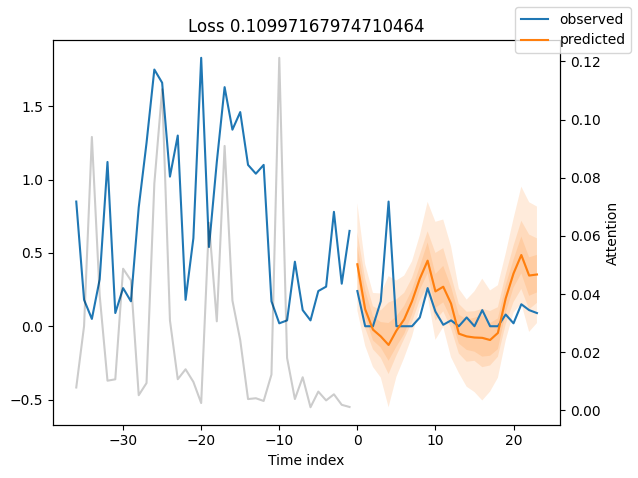

In [7]:
# Cell 3: Tạo dataset, train TFT và đánh giá
torch.set_float32_matmul_precision("high")
from pytorch_forecasting.metrics import MAE, QuantileLoss
from sklearn.metrics import r2_score

max_encoder_length = 36    # 36 tháng nhìn lại
max_prediction_length = 24 # TĂNG LÊN 24 (hoặc xa hơn) ĐỂ KIỂM TRA MÔ HÌNH CÓ BỊ ĐI NGANG KHÔNG
batch_size = 128

# Chỉ giữ các chuỗi đủ dài để train
min_required_length = max_encoder_length + max_prediction_length
series_lengths = data.groupby(['entity', 'series'])['time_idx'].nunique().reset_index(name='n_steps')
valid_groups = series_lengths.loc[series_lengths['n_steps'] >= min_required_length, ['entity', 'series']]

train_df = data.merge(valid_groups, on=['entity', 'series'], how='inner').copy()

if train_df.empty:
    raise ValueError('Khong co chuoi nao du do dai de train. Hay giam max_encoder_length/max_prediction_length.')

training_cutoff = train_df['time_idx'].max() - max_prediction_length

# BƯỚC SỬA LỖI LEAKAGE: 
known_candidates = [
    'time_idx', 'month_sin', 'month_cos',
    'precipitation', 'solar', 'humidity', 'temperature'
]
unknown_candidates = [
    'generation_TWh',
    'target_lag_1', 'target_lag_3', 'target_lag_6', 'target_lag_12',
    'target_roll_mean_3', 'target_roll_mean_6', 'target_roll_mean_12',
    'target_roll_std_3', 'target_roll_std_6', 'target_roll_std_12'
]

known_reals = [c for c in known_candidates if c in train_df.columns]
unknown_reals = [c for c in unknown_candidates if c in train_df.columns]

training = TimeSeriesDataSet(
    train_df[lambda x: x.time_idx <= training_cutoff],
    time_idx='time_idx',
    target='generation_TWh',
    group_ids=['entity', 'series'],
    min_encoder_length=max_encoder_length // 2,
    max_encoder_length=max_encoder_length,
    min_prediction_length=1,
    max_prediction_length=max_prediction_length,
    static_categoricals=['entity', 'series'],
    time_varying_known_categoricals=['month'],
    time_varying_known_reals=known_reals,
    time_varying_unknown_reals=unknown_reals,
    # Bỏ transformation='standard' vì GroupNormalizer không hỗ trợ key này. 
    # Mặc định (nếu không đặt transformation hoặc đặt là None/False) nó sẽ dùng Standard Scaling (chuẩn hóa z-score)
    target_normalizer=GroupNormalizer(groups=['entity', 'series'], center=True),
    lags={'generation_TWh': [1, 2, 3, 6, 12]},  
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
    allow_missing_timesteps=True,
)

validation = TimeSeriesDataSet.from_dataset(training, train_df, predict=True, stop_randomization=True)

train_loader = training.to_dataloader(train=True, batch_size=batch_size, num_workers=0)
val_loader = validation.to_dataloader(train=False, batch_size=batch_size * 2, num_workers=0)

early_stop_callback = EarlyStopping(monitor='val_loss', min_delta=1e-4, patience=10, verbose=True, mode='min')
lr_logger = LearningRateMonitor()
logger = CSVLogger('lightning_logs', name='tft_generation_mae_stable_premodel')

trainer = Trainer(
    max_epochs=50,
    accelerator='gpu' if torch.cuda.is_available() else 'cpu',
    devices=1,
    gradient_clip_val=0.1,
    callbacks=[lr_logger, early_stop_callback],
    logger=logger,
    enable_model_summary=True,
)

tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=1e-3,
    hidden_size=64,             
    attention_head_size=4,      
    dropout=0.1,                
    hidden_continuous_size=32,  
    loss=QuantileLoss(), # Sử dụng QuantileLoss truyền thống của TFT để capture được distribution và có median tốt hơn
    log_interval=50,
    reduce_on_plateau_patience=4,
)

print(f'So tham so model: {tft.size()/1e3:.1f}k')
trainer.fit(tft, train_dataloaders=train_loader, val_dataloaders=val_loader)

# Du doan tren validation để vẽ
torch.set_grad_enabled(False)
raw_pred_obj = tft.predict(val_loader, mode='raw', return_x=True)

if hasattr(raw_pred_obj, 'output'):
    raw_predictions = raw_pred_obj.output
    x = getattr(raw_pred_obj, 'x', None)
elif isinstance(raw_pred_obj, tuple):
    raw_predictions = raw_pred_obj[0]
    x = raw_pred_obj[1] if len(raw_pred_obj) > 1 else None
else:
    raw_predictions = raw_pred_obj
    x = None

point_pred_obj = tft.predict(val_loader, mode='prediction')
point_predictions = point_pred_obj.output if hasattr(point_pred_obj, 'output') else point_pred_obj

actuals = torch.cat([y[0] for _, y in iter(val_loader)])
mae = (actuals - point_predictions).abs().mean().item()
rmse = torch.sqrt(((actuals - point_predictions) ** 2).mean()).item()
wape = ((actuals - point_predictions).abs().sum() / (actuals.abs().sum() + 1e-8)).item() * 100

y_true_np = actuals.detach().cpu().numpy().reshape(-1)
y_pred_np = point_predictions.detach().cpu().numpy().reshape(-1)
r2 = r2_score(y_true_np, y_pred_np)

print(f'Validation MAE : {mae:.4f}')
print(f'Validation RMSE: {rmse:.4f}')
print(f'Validation WAPE: {wape:.4f}%')
print(f'Validation R2  : {r2:.4f}')

# Chọn chuỗi có lỗi trung vị để vẽ tránh bias do idx=0
err_per_series = (actuals - point_predictions).abs().mean(dim=1)
idx_plot = int(torch.argsort(err_per_series)[len(err_per_series) // 2].item())
if x is not None:
    _ = tft.plot_prediction(x, raw_predictions, idx=idx_plot, add_loss_to_title=True)

In [ ]:
# Cell 5: Đánh giá lệch cực đoan theo quantile target
import pandas as pd
from sklearn.metrics import r2_score
import numpy as np

# Flatten để tính metric theo mức độ lớn/nhỏ của target
y_true = actuals.detach().cpu().numpy().reshape(-1)
y_pred = point_predictions.detach().cpu().numpy().reshape(-1)
err = np.abs(y_true - y_pred)

eval_df = pd.DataFrame({
    "y_true": y_true,
    "y_pred": y_pred,
    "abs_error": err
})

q10 = eval_df["y_true"].quantile(0.10)
q90 = eval_df["y_true"].quantile(0.90)

low_df = eval_df[eval_df["y_true"] <= q10]
mid_df = eval_df[(eval_df["y_true"] > q10) & (eval_df["y_true"] < q90)]
high_df = eval_df[eval_df["y_true"] >= q90]

def calc_wape(df_sub):
    if len(df_sub) == 0: return 0.0
    return (df_sub['abs_error'].sum() / (df_sub['y_true'].abs().sum() + 1e-8)) * 100

overall_wape = calc_wape(eval_df)
low_wape = calc_wape(low_df)
mid_wape = calc_wape(mid_df)
high_wape = calc_wape(high_df)

print(f"Overall MAE : {eval_df['abs_error'].mean():.4f}")
print(f"Overall WAPE: {overall_wape:.4f}%")
try:
    print(f"Overall R2  : {r2_score(eval_df['y_true'], eval_df['y_pred']):.4f}")
except:
    pass

print(f"\nLow 10%  (<= {q10:.2f}) -> MAE: {low_df['abs_error'].mean():.4f} | WAPE: {low_wape:.4f}% (n={len(low_df)})")
print(f"Mid 80%           -> MAE: {mid_df['abs_error'].mean():.4f} | WAPE: {mid_wape:.4f}% (n={len(mid_df)})")
print(f"High 10% (>= {q90:.2f}) -> MAE: {high_df['abs_error'].mean():.4f} | WAPE: {high_wape:.4f}% (n={len(high_df)})")

# Bias hướng ở vùng cao (dương: dự báo cao hơn thực tế, âm: dự báo thấp hơn thực tế)
high_bias = (high_df["y_pred"] - high_df["y_true"]).mean()
print(f"\nHigh 10% mean bias: {high_bias:.4f}")

Overall MAE : 0.5232
Overall WAPE: 14.0710%
Overall R2  : 0.9823

Low 10%  (<= 0.02) -> MAE: 0.0218 | WAPE: 400.4626% (n=254)
Mid 80%           -> MAE: 0.3070 | WAPE: 19.0529% (n=2014)
High 10% (>= 7.65) -> MAE: 2.7562 | WAPE: 11.3433% (n=252)

High 10% mean bias: -1.8550


In [ ]:
# Cell 6: Lưu cấu hình và model
import shutil
import os

model_save_path = "checkpoint/tft_model_best.ckpt"

# Lưu trực tiếp state cuối cùng của model
trainer.save_checkpoint("checkpoint/tft_model_latest.ckpt")
print("Đã lưu mô hình mới nhất (cuối quá trình train) tại: checkpoint/tft_model_latest.ckpt")

# Nếu EarlyStopping được dùng và đã trích xuất best_model_path:
if trainer.checkpoint_callback and trainer.checkpoint_callback.best_model_path:
    best_path = trainer.checkpoint_callback.best_model_path
    print(f"File checkpoint model tốt nhất (tự động lưu bởi Lightning): {best_path}")
    
    # Copy file best model ra folder checkpoint để dễ quản lý
    os.makedirs("checkpoint", exist_ok=True)
    shutil.copy(best_path, model_save_path)
    print(f"Đã copy mô hình tốt nhất sang dễ truy cập tại: {model_save_path}")

# Sau này bạn có thể load lại mô hình để dự báo tiếp bằng cách:
# from pytorch_forecasting import TemporalFusionTransformer
# loaded_tft = TemporalFusionTransformer.load_from_checkpoint("checkpoint/tft_model_best.ckpt")

INFO: `weights_only` was not set, defaulting to `False`.


[11:52:33] INFO     `weights_only` was not set,     checkpoint_connector.py:455
                    defaulting to `False`.                                     


Đã lưu mô hình mới nhất (cuối quá trình train) tại: checkpoint/tft_model_latest.ckpt
File checkpoint model tốt nhất (tự động lưu bởi Lightning): lightning_logs\tft_generation_mae_stable_premodel\version_2\checkpoints\epoch=29-step=1770.ckpt
Đã copy mô hình tốt nhất sang dễ truy cập tại: checkpoint/tft_model_best.ckpt


INFO: GPU available: True (cuda), used: True


           INFO     GPU available: True (cuda), used: True         setup.py:164


INFO: TPU available: False, using: 0 TPU cores


           INFO     TPU available: False, using: 0 TPU cores       setup.py:167


INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


...

           INFO     💡 Tip: For seamless cloud logging   logger_connector.py:91
                    and experiment tracking, try                               
                    installing                                                 
                    [litlogger](https://pypi.org/project                       
                    /litlogger/) to enable LitLogger,                          
                    which logs metrics and artifacts                           
                    automatically to the Lightning                             
                    Experiments platform.                                      


INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


           INFO     💡 Tip: For seamless cloud        callback_connector.py:190
                    uploads and versioning, try                                
                    installing                                                 
                    [litmodels](https://pypi.org/proj                          
                    ect/litmodels/) to enable                                  
                    LitModelCheckpoint, which syncs                            
                    automatically with the Lightning                           
                    model registry.                                            


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


           INFO     LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]        cuda.py:61
pred shape: (105, 24)
actual shape: (105, 24)
MAE : 0.5232
RMSE: 1.5222
WAPE: 14.0710%
R2  : 0.9823


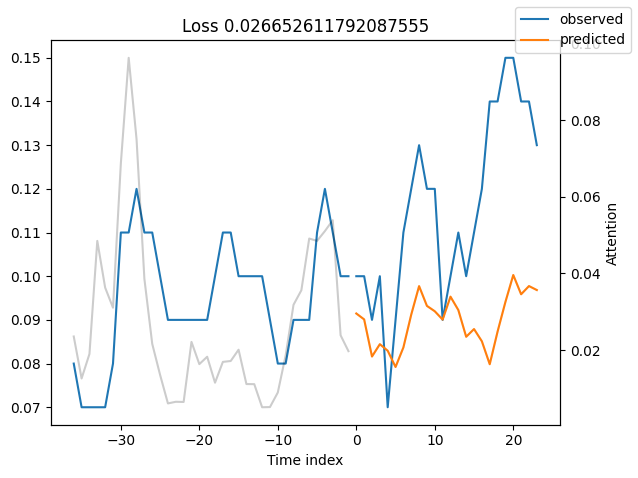

In [ ]:
# Cell 4: Đánh giá nhanh từ model đã train trong kernel (không train lại)
from sklearn.metrics import r2_score

raw_pred_obj = tft.predict(val_loader, mode="raw", return_x=True)
if hasattr(raw_pred_obj, "output") and hasattr(raw_pred_obj, "x"):
    raw_predictions = raw_pred_obj.output
    x = raw_pred_obj.x
elif isinstance(raw_pred_obj, tuple) and len(raw_pred_obj) >= 2:
    raw_predictions, x = raw_pred_obj[0], raw_pred_obj[1]
else:
    raw_predictions, x = raw_pred_obj, None

point_pred_obj = tft.predict(val_loader, mode="prediction")
point_predictions = point_pred_obj.output if hasattr(point_pred_obj, "output") else point_pred_obj
actuals = torch.cat([y[0] for _, y in iter(val_loader)])

mae = (actuals - point_predictions).abs().mean().item()
rmse = torch.sqrt(((actuals - point_predictions) ** 2).mean()).item()
# Đổi MAPE sang WAPE:
wape = ((actuals - point_predictions).abs().sum() / (actuals.abs().sum() + 1e-8)).item() * 100

y_true_np = actuals.detach().cpu().numpy().reshape(-1)
y_pred_np = point_predictions.detach().cpu().numpy().reshape(-1)
r2 = r2_score(y_true_np, y_pred_np)

print("pred shape:", tuple(point_predictions.shape))
print("actual shape:", tuple(actuals.shape))
print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"WAPE: {wape:.4f}%")
print(f"R2  : {r2:.4f}")

if x is not None:
    _ = tft.plot_prediction(x, raw_predictions, idx=0, add_loss_to_title=True)